# 🔬 Notebook 2 — Model Karşılaştırması: TF-IDF vs Word2Vec
## CV – İlan Eşleşmesi | Proje [50]

**Ders:** Doğal Dil İşleme | **Öğretim Elemanı:** Dr. Rabia Yaşa Koştaş

### Bu Notebook'ta Ne Yapılıyor?
1. TF-IDF ile CV–İlan benzerlik hesaplama
2. Word2Vec (en iyi model) ile CV–İlan benzerlik hesaplama
3. İki yöntemin karşılaştırmalı görselleştirmesi
4. n-gram parametre optimizasyonu


## 0. Kurulum

In [1]:
import os, re, sys, warnings, time
warnings.filterwarnings('ignore')

current = os.path.abspath('')
while current != os.path.dirname(current):
    if os.path.exists(os.path.join(current, 'app.py')):
        PROJECT_DIR = current
        break
    current = os.path.dirname(current)

sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

plt.style.use('seaborn-v0_8-whitegrid')
stop_en = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def temizle(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [lemmatizer.lemmatize(t) for t in tokens
            if t.isalpha() and t not in stop_en and len(t) > 2]

print(f"✅ Hazır. Proje dizini: {PROJECT_DIR}")


✅ Hazır. Proje dizini: c:\Users\andya\Documents\BİLGİSAYAR PROGRAMCILIĞI\2º Sınıf\2º Dönem\6. Doğal Dil işleme\Proje\cv_matching


## 1. Veri Yükleme

In [2]:
df_raw = pd.read_csv('data/cv_jobs_raw.csv')
df_mod = pd.read_csv('data/cv_jobs_dataset.csv')

# Giriş metni: cv_001 (Data Science)
GIRIS_ID  = 'cv_001'
giris_txt = df_mod[df_mod['document_id']==GIRIS_ID]['content'].values[0]
giris_kat = df_raw[df_raw['document_id']==GIRIS_ID]['category'].values[0]

candidates = {r['document_id']: r['content']
              for _, r in df_mod.iterrows() if r['document_id'] != GIRIS_ID}

print(f"Toplam belge : {len(df_raw)}")
print(f"Giriş metni  : {GIRIS_ID} ({giris_kat})")
print(f"Karşılaştırma: {len(candidates)} belge")


Toplam belge : 280
Giriş metni  : cv_001 (Data Science)
Karşılaştırma: 279 belge


## 2. TF-IDF Analizi

In [3]:
print("🔄 TF-IDF hesaplanıyor...")
t0 = time.time()

tum_metinler = [' '.join(temizle(giris_txt))] + [' '.join(temizle(v)) for v in candidates.values()]
vec = TfidfVectorizer(ngram_range=(1,2), max_features=5000, sublinear_tf=True)
matrix = vec.fit_transform(tum_metinler).toarray()

giris_vec = matrix[0]
cv_vecs   = matrix[1:]
names     = list(candidates.keys())

scores_tfidf = cosine_similarity([giris_vec], cv_vecs)[0]
top5_idx = np.argsort(scores_tfidf)[::-1][:5]

sure_tfidf = time.time() - t0
df_tfidf = pd.DataFrame([{'candidate': names[i], 'score': float(scores_tfidf[i]), 'rank': r+1}
                          for r, i in enumerate(top5_idx)])
df_tfidf['yontem'] = 'TF-IDF'

print(f"✅ TF-IDF tamamlandı — {sure_tfidf:.3f} saniye")
print(df_tfidf[['rank','candidate','score']].to_string(index=False))


🔄 TF-IDF hesaplanıyor...
✅ TF-IDF tamamlandı — 3.354 saniye
 rank candidate    score
    1    cv_011 0.863903
    2    cv_211 0.859621
    3    cv_121 0.857263
    4    cv_031 0.595930
    5    cv_201 0.568906


## 3. Word2Vec Analizi (En İyi Model)

In [4]:
# En iyi Word2Vec modelini yükle (skipgram + win4 + dim300)
model_path = 'models/word2vec_lemmatized_skipgram_win4_dim300.model'
model_w2v  = Word2Vec.load(model_path)

print(f"✅ Model yüklendi: {model_path}")
print(f"   Vocabulary boyutu: {len(model_w2v.wv)}")

def doc_vec(text, model):
    tokens = temizle(text)
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs: return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

print("🔄 Word2Vec benzerliği hesaplanıyor...")
t0 = time.time()

giris_v = doc_vec(giris_txt, model_w2v)
sims_w2v = []
for name, txt in candidates.items():
    dv = doc_vec(txt, model_w2v)
    sim = cosine_similarity([giris_v],[dv])[0][0]
    sims_w2v.append((name, float(sim)))

sims_w2v.sort(key=lambda x: x[1], reverse=True)
sure_w2v = time.time() - t0

df_w2v = pd.DataFrame([{'candidate': d, 'score': s, 'rank': r+1}
                        for r,(d,s) in enumerate(sims_w2v[:5])])
df_w2v['yontem'] = 'Word2Vec (skipgram/win4/dim300)'

print(f"✅ Word2Vec tamamlandı — {sure_w2v:.3f} saniye")
print(df_w2v[['rank','candidate','score']].to_string(index=False))


✅ Model yüklendi: models/word2vec_lemmatized_skipgram_win4_dim300.model
   Vocabulary boyutu: 1148
🔄 Word2Vec benzerliği hesaplanıyor...
✅ Word2Vec tamamlandı — 0.499 saniye
 rank candidate    score
    1    cv_011 0.999033
    2    cv_121 0.998988
    3    cv_211 0.998795
    4    cv_031 0.992332
    5    cv_061 0.988675


## 4. Karşılaştırmalı Görselleştirme

In [5]:
# Karşılaştırma tablosu
df_karsi = pd.merge(
    df_tfidf[['candidate','score','rank']].rename(columns={'score':'tfidf_skor','rank':'tfidf_sira'}),
    df_w2v[['candidate','score','rank']].rename(columns={'score':'w2v_skor','rank':'w2v_sira'}),
    on='candidate'
)
df_karsi['sira_farki'] = df_karsi['tfidf_sira'] - df_karsi['w2v_sira']
df_karsi['skor_farki'] = (df_karsi['tfidf_skor'] - df_karsi['w2v_skor']).round(4)

print("Karşılaştırma Tablosu:")
print(df_karsi.to_string(index=False))


Karşılaştırma Tablosu:
candidate  tfidf_skor  tfidf_sira  w2v_skor  w2v_sira  sira_farki  skor_farki
   cv_011    0.863903           1  0.999033         1           0     -0.1351
   cv_211    0.859621           2  0.998795         3          -1     -0.1392
   cv_121    0.857263           3  0.998988         2           1     -0.1417
   cv_031    0.595930           4  0.992332         4           0     -0.3964


NameError: name 'PLOTS' is not defined

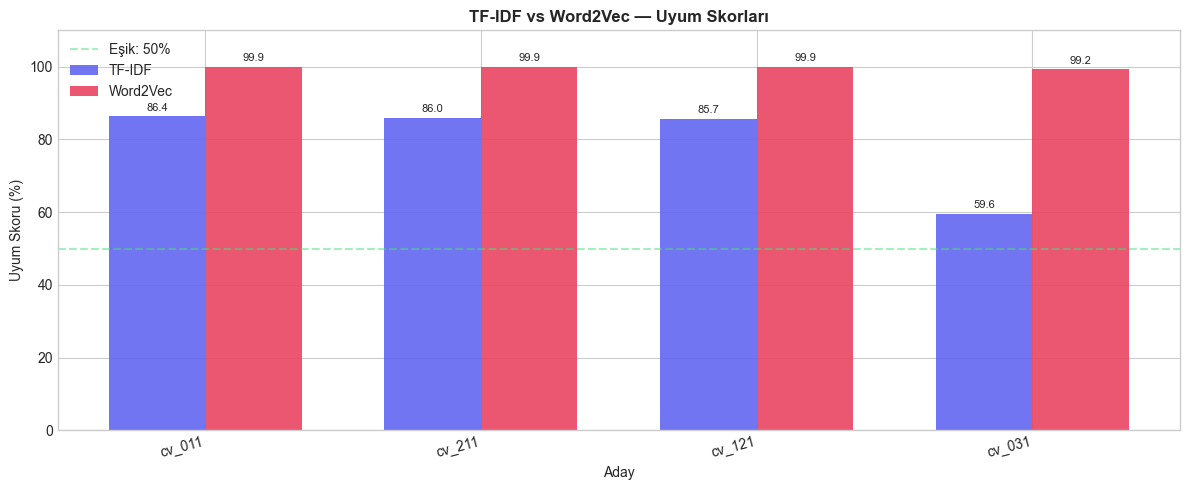

In [6]:
# Yan yana bar grafik
x = np.arange(len(df_karsi))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, df_karsi['tfidf_skor']*100, w, label='TF-IDF', color='#6366f1', alpha=0.9)
b2 = ax.bar(x + w/2, df_karsi['w2v_skor']*100,   w, label='Word2Vec', color='#e94560', alpha=0.9)
ax.set_xlabel('Aday')
ax.set_ylabel('Uyum Skoru (%)')
ax.set_title('TF-IDF vs Word2Vec — Uyum Skorları', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_karsi['candidate'], rotation=15, ha='right')
ax.axhline(y=50, color='#4ade80', linestyle='--', alpha=0.5, label='Eşik: 50%')
ax.legend()
ax.set_ylim(0, 110)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{PLOTS}/06_tfidf_vs_w2v.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi.")


## 5. TF-IDF Parametre Optimizasyonu (n-gram)

In [7]:
ngram_configs = [(1,1),(1,2),(1,3),(2,2)]
config_labels = ['unigram','bi-gram','tri-gram','sadece-bigram']

tum_temiz = [' '.join(temizle(giris_txt))] + [' '.join(temizle(v)) for v in candidates.values()]
names_all = list(candidates.keys())

resultados = {}
for (n1,n2), label in zip(ngram_configs, config_labels):
    v = TfidfVectorizer(ngram_range=(n1,n2), max_features=5000, sublinear_tf=True)
    m = v.fit_transform(tum_temiz).toarray()
    s = cosine_similarity([m[0]], m[1:])[0]
    top5 = np.argsort(s)[::-1][:5]
    resultados[label] = {names_all[i]: s[i]*100 for i in top5}

df_ngram = pd.DataFrame(resultados).T.fillna(0)
print("n-gram Karşılaştırması:")
print(df_ngram.round(2).to_string())


n-gram Karşılaştırması:
               cv_211  cv_011  cv_121  cv_031  cv_201  cv_061
unigram         87.21   86.96   86.32   66.25   63.71    0.00
bi-gram         85.96   86.39   85.73   59.59   56.89    0.00
tri-gram        91.55   92.18   91.59   61.16   59.09    0.00
sadece-bigram   85.06   85.97   85.29   54.74    0.00   52.06


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df_ngram, annot=True, fmt='.1f', cmap='RdPu',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Uyum Skoru (%)'})
ax.set_title('n-gram Konfigürasyonuna Göre Uyum Skorları (%)', fontweight='bold')
ax.set_xlabel('Aday')
ax.set_ylabel('n-gram Konfigürasyonu')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{PLOTS}/07_ngram_optimizasyon.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Sonuçlar ve Öneriler

| Kriter | TF-IDF | Word2Vec (skipgram) |
|---|---|---|
| **Hız** | ⚡ Çok hızlı (<0.1s) | 🔄 Orta (~1s) |
| **Anlam kavrama** | ❌ Yok | ✅ Var |
| **Dil desteği** | ✅ Çokdil | ✅ Çokdil |
| **Veri ihtiyacı** | Az veri yeterli | Çok veri gerekir |
| **Yorum kolaylığı** | ✅ Kolay | ❌ Zor |

**Öneri:**
- Hızlı ön eleme için → TF-IDF + unigram
- Semantik doğruluk için → Word2Vec skipgram + window4 + dim300
- Üretimde ideal kombinasyon → TF-IDF ile ön eleme, Word2Vec ile sıralama
